# Trio 2 Weekly VaR and CVaR Analysis

This notebook studies 5% VaR and CVaR using weekly log returns for HDFC Bank, HUL, and TCS.

VaR gives the weekly tail-loss threshold. CVaR gives the average weekly loss beyond that threshold. This trio compares banking, FMCG, and IT sector risk using the same framework.

## Imports and settings

The setup follows the same style as the daily trio notebook, but all returns are converted to weekly frequency before risk metrics are calculated.

In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from risk_metrics import (
    historical_var,
    historical_cvar,
    parametric_var,
    parametric_cvar,
)

ALPHA = 0.05
DATA_DIR = Path("datasets") / "trio2_5yr"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.5f}".format)

plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

## Load and inspect datasets

The source files contain daily prices. The notebook first inspects each file, then detects the date and close-price columns before weekly conversion.

In [20]:
asset_files = {
    "HDFC Bank": DATA_DIR / "hdfc_5yr_daily.xlsx",
    "HUL": DATA_DIR / "hul_5yr_daily.xlsx",
    "TCS": DATA_DIR / "tcs_5yr_daily.xlsx",
}

sector_labels = {
    "HDFC Bank": "banking stock",
    "HUL": "FMCG stock",
    "TCS": "IT stock",
}


def read_excel_safely(path):
    df = pd.read_excel(path)

    # Some exports have an empty header row. Re-read without headers and assign simple names.
    unnamed = [str(col).lower().startswith("unnamed") for col in df.columns]
    if sum(unnamed) >= max(1, len(df.columns) - 1):
        df = pd.read_excel(path, header=None)
        df = df.dropna(how="all").reset_index(drop=True)

        if df.shape[1] == 7:
            df.columns = ["Date", "Adj Close", "Close", "High", "Low", "Volume", "Daily Return"]
        elif df.shape[1] == 6:
            df.columns = ["Date", "Open", "High", "Low", "Close", "Volume"]
        else:
            df.columns = ["Date"] + [f"Column_{i}" for i in range(1, df.shape[1])]

    df.columns = [str(col).strip() for col in df.columns]
    return df


raw_data = {}

for asset, path in asset_files.items():
    df = read_excel_safely(path)
    raw_data[asset] = df

    print(f"\n{asset} ({sector_labels[asset]})")
    print("Path:", path)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    display(df.head())


HDFC Bank (banking stock)
Path: datasets/trio2_5yr/hdfc_5yr_daily.xlsx
Shape: (1235, 7)
Columns: ['Date', 'Close_HDFCBANK.NS', 'High_HDFCBANK.NS', 'Low_HDFCBANK.NS', 'Open_HDFCBANK.NS', 'Volume_HDFCBANK.NS', 'Daily Return']


,Date,Close_HDFCBANK.NS,High_HDFCBANK.NS,Low_HDFCBANK.NS,Open_HDFCBANK.NS,Volume_HDFCBANK.NS,Daily Return
0,2021-04-20,658.95007,675.52565,655.42181,674.86261,23186270,NaN
1,2021-04-22,673.67865,675.71510,649.31258,653.55117,38485312,0.02235
2,2021-04-23,669.72418,679.40903,663.11760,667.28519,22713528,-0.00587
3,2021-04-26,665.29614,676.75694,664.32526,669.17954,30170952,-0.00661
4,2021-04-27,681.35071,682.91357,665.29613,666.45640,20592906,0.02413



HUL (FMCG stock)
Path: datasets/trio2_5yr/hul_5yr_daily.xlsx
Shape: (1235, 7)
Columns: ['Date', 'Close_HINDUNILVR.NS', 'High_HINDUNILVR.NS', 'Low_HINDUNILVR.NS', 'Open_HINDUNILVR.NS', 'Volume_HINDUNILVR.NS', 'Daily Return']


,Date,Close_HINDUNILVR.NS,High_HINDUNILVR.NS,Low_HINDUNILVR.NS,Open_HINDUNILVR.NS,Volume_HINDUNILVR.NS,Daily Return
0,2021-04-20,2204.70776,2258.55070,2192.15524,2258.55070,1589508,NaN
1,2021-04-22,2160.52124,2197.85732,2144.52019,2197.85732,1721265,-0.02004
2,2021-04-23,2122.21948,2161.07281,2115.09254,2151.87676,1949756,-0.01773
3,2021-04-26,2170.86621,2179.28073,2125.20790,2137.16277,1946867,0.02292
4,2021-04-27,2188.52319,2194.59245,2163.78567,2173.02775,1668456,0.00813



TCS (IT stock)
Path: datasets/trio2_5yr/tcs_5yr_daily.xlsx
Shape: (1235, 7)
Columns: ['Date', 'Close_TCS.NS', 'High_TCS.NS', 'Low_TCS.NS', 'Open_TCS.NS', 'Volume_TCS.NS', 'Daily Return']


,Date,Close_TCS.NS,High_TCS.NS,Low_TCS.NS,Open_TCS.NS,Volume_TCS.NS,Daily Return
0,2021-04-20,2764.30127,2835.33072,2748.30211,2835.02296,3141893,NaN
1,2021-04-22,2741.66553,2767.33453,2729.75399,2767.33453,1988980,-0.00819
2,2021-04-23,2733.48975,2741.84098,2717.27082,2729.53390,1615309,-0.00298
3,2021-04-26,2725.84229,2771.73007,2714.63405,2726.94113,2490260,-0.00280
4,2021-04-27,2753.26929,2756.87359,2727.77605,2730.41328,1471417,0.01006


## Cleaning, weekly conversion, and return calculation

Daily prices are cleaned first. Weekly prices are then formed using the last available closing price of each week, and weekly log returns are computed from those weekly prices.

In [21]:
def clean_name(name):
    return str(name).strip().lower().replace("_", " ").replace("-", " ")


def parse_dates(series):
    numeric = pd.to_numeric(series, errors="coerce")
    numeric_share = numeric.notna().mean()

    # Excel serial dates usually sit around 40,000-50,000 for recent market data.
    if numeric_share > 0.8 and numeric.dropna().between(20000, 60000).mean() > 0.8:
        return pd.to_datetime(numeric, unit="D", origin="1899-12-30", errors="coerce")

    return pd.to_datetime(series, errors="coerce", dayfirst=True)


def detect_date_column(df):
    for col in df.columns:
        if "date" in clean_name(col):
            return col

    scores = {}
    for col in df.columns:
        scores[col] = parse_dates(df[col]).notna().mean()

    best_col = max(scores, key=scores.get)
    if scores[best_col] < 0.6:
        raise ValueError("Could not detect a reliable date column.")
    return best_col


def detect_price_column(df, date_col):
    candidates = [col for col in df.columns if col != date_col]
    names = {col: clean_name(col) for col in candidates}

    # Adjusted close is usually best for return analysis if it exists.
    preferred = [
        "adj close", "adjusted close", "close", "closing price",
        "price", "ltp", "last price", "last"
    ]

    for target in preferred:
        for col, name in names.items():
            if name == target:
                return col

    for target in preferred:
        for col, name in names.items():
            if target in name:
                return col

    numeric_cols = []
    for col in candidates:
        numeric_share = pd.to_numeric(df[col], errors="coerce").notna().mean()
        if numeric_share > 0.8:
            numeric_cols.append(col)

    if not numeric_cols:
        raise ValueError("Could not detect a reliable price column.")

    return numeric_cols[0]


def prepare_asset_weekly(df, asset_name):
    date_col = detect_date_column(df)
    price_col = detect_price_column(df, date_col)

    print(f"{asset_name}: selected date column = '{date_col}', price column = '{price_col}'")

    daily = pd.DataFrame({
        "Date": parse_dates(df[date_col]),
        "Price": pd.to_numeric(df[price_col], errors="coerce"),
    })

    before = len(daily)
    daily = daily.dropna(subset=["Date", "Price"])
    daily = daily.drop_duplicates(subset="Date", keep="last")
    daily = daily.sort_values("Date").reset_index(drop=True)

    weekly = (
        daily.set_index("Date")
        .resample("W-FRI")["Price"]
        .last()
        .dropna()
        .reset_index()
    )
    weekly["Weekly Log Return"] = np.log(weekly["Price"] / weekly["Price"].shift(1))
    weekly = weekly.dropna(subset=["Weekly Log Return"]).reset_index(drop=True)

    print(f"{asset_name}: daily rows before cleaning = {before}, weekly return rows = {len(weekly)}")
    return daily, weekly


daily_price_data = {}
weekly_data = {}
weekly_returns = {}

for asset, df in raw_data.items():
    daily, weekly = prepare_asset_weekly(df, asset)
    daily_price_data[asset] = daily
    weekly_data[asset] = weekly
    weekly_returns[asset] = weekly["Weekly Log Return"]
    display(weekly.head())

HDFC Bank: selected date column = 'Date', price column = 'Close_HDFCBANK.NS'
HDFC Bank: daily rows before cleaning = 1235, weekly return rows = 260


,Date,Price,Weekly Log Return
0,2021-04-30,668.84808,-0.00131
1,2021-05-07,670.00836,0.00173
2,2021-05-14,656.79529,-0.01992
3,2021-05-21,709.10303,0.07663
4,2021-05-28,712.01550,0.00410


HUL: selected date column = 'Date', price column = 'Close_HINDUNILVR.NS'
HUL: daily rows before cleaning = 1235, weekly return rows = 260


,Date,Price,Weekly Log Return
0,2021-04-30,2164.52148,0.01974
1,2021-05-07,2217.35229,0.02411
2,2021-05-14,2185.76440,-0.01435
3,2021-05-21,2172.33789,-0.00616
4,2021-05-28,2135.04761,-0.01732


TCS: selected date column = 'Date', price column = 'Close_TCS.NS'
TCS: daily rows before cleaning = 1235, weekly return rows = 260


,Date,Price,Weekly Log Return
0,2021-04-30,2668.56934,-0.02404
1,2021-05-07,2754.06006,0.03153
2,2021-05-14,2682.50342,-0.02633
3,2021-05-21,2707.99634,0.00946
4,2021-05-28,2776.98364,0.02516


## Baseline descriptive metrics

These weekly summary statistics give a first view of average return, volatility, and distribution shape before the tail-risk calculations.

In [22]:
descriptive_rows = []

for asset, r in weekly_returns.items():
    descriptive_rows.append({
        "Asset": asset,
        "Number of Observations": int(r.count()),
        "Mean Weekly Return": r.mean(),
        "Weekly Std Dev": r.std(ddof=1),
        "Minimum Weekly Return": r.min(),
        "Maximum Weekly Return": r.max(),
        "Skewness": r.skew(),
        "Kurtosis": r.kurtosis(),
    })

descriptive_table = pd.DataFrame(descriptive_rows).set_index("Asset")
descriptive_table.style.format({
    "Mean Weekly Return": "{:.5f}",
    "Weekly Std Dev": "{:.5f}",
    "Minimum Weekly Return": "{:.5f}",
    "Maximum Weekly Return": "{:.5f}",
    "Skewness": "{:.3f}",
    "Kurtosis": "{:.3f}",
})

,Number of Observations,Mean Weekly Return,Weekly Std Dev,Minimum Weekly Return,Maximum Weekly Return,Skewness,Kurtosis
Asset,,,,,,,
HDFC Bank,260,0.00068,0.02716,-0.10972,0.07663,-0.300,1.329
HUL,260,0.00021,0.02838,-0.07663,0.10148,0.394,1.117
TCS,260,-0.00022,0.03010,-0.08908,0.06401,-0.586,0.657


### Baseline visual checks

These plots make the weekly return distribution and shape statistics easier to compare before moving to VaR and CVaR.

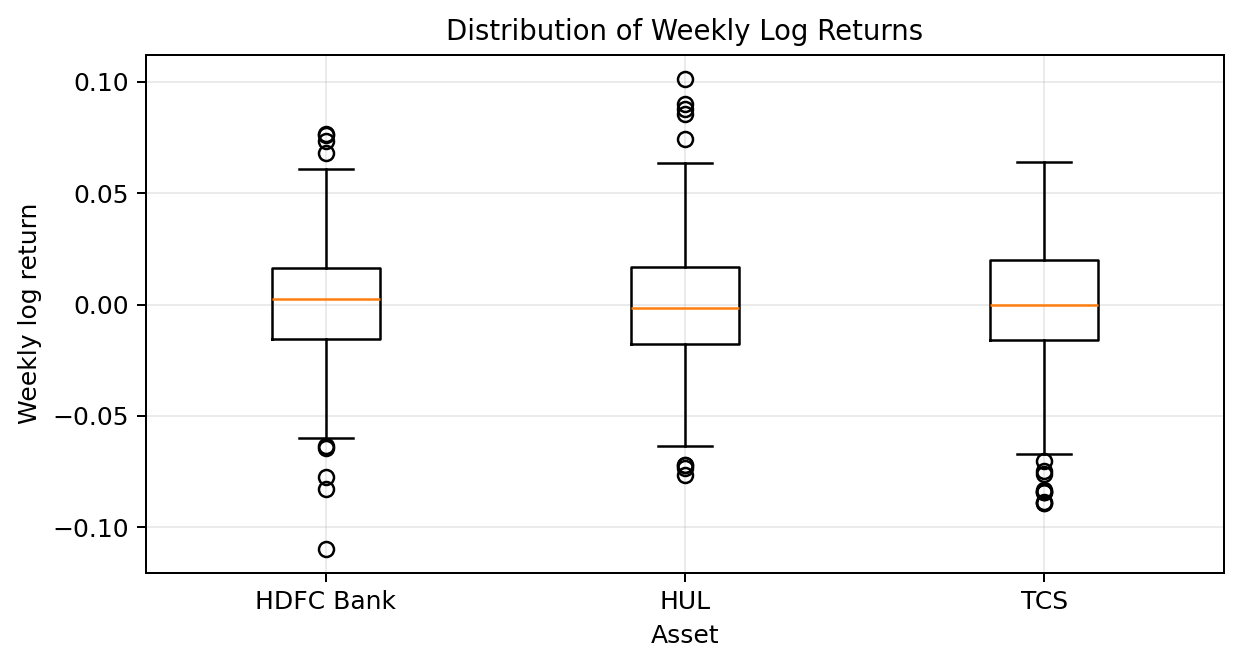

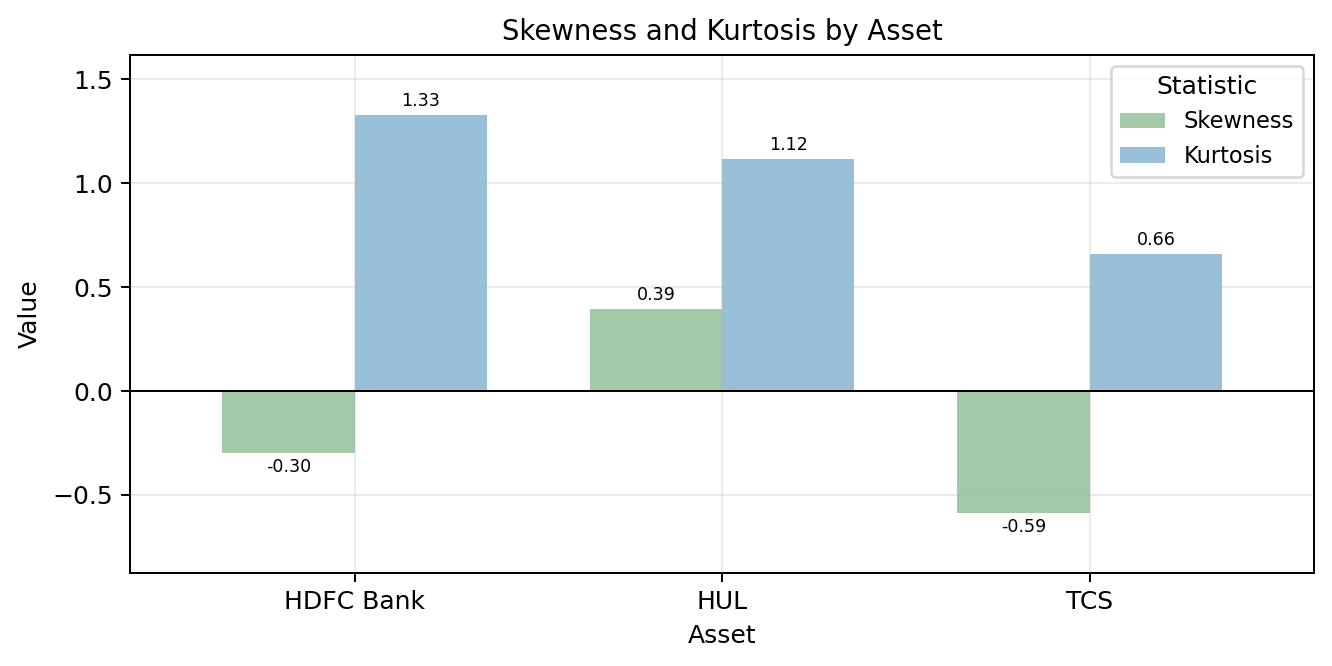

In [23]:
baseline_color = ["#A3C9A8", "#98C1D9"]

fig, ax = plt.subplots(figsize=(7, 3.8), dpi=180)
return_values = [weekly_returns[asset].dropna().values for asset in asset_files.keys()]
ax.boxplot(return_values, tick_labels=list(asset_files.keys()), showfliers=True)
ax.set_title("Distribution of Weekly Log Returns")
ax.set_xlabel("Asset")
ax.set_ylabel("Weekly log return")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

shape_cols = ["Skewness", "Kurtosis"]
ax = descriptive_table[shape_cols].plot(kind="bar", figsize=(7.5, 3.8), width=0.72, color=baseline_color)
ax.set_title("Skewness and Kurtosis by Asset")
ax.set_xlabel("Asset")
ax.set_ylabel("Value")
ax.legend(title="Statistic")
ax.axhline(0, color="black", linewidth=0.8)

for container in ax.containers:
    labels = [f"{value:.2f}" for value in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2, fontsize=7)

ax.margins(y=0.15)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Skewness
Skewness measures the **asymmetry** of a distribution around its mean.

$$
\text{Skewness} = \frac{\mathbb{E}\left[(X-\mu)^3\right]}{\sigma^3}
$$

- $\text{Skewness} > 0$: right-skewed distribution with a longer right tail
- $\text{Skewness} < 0$: left-skewed distribution with a longer left tail
- $\text{Skewness} = 0$: symmetric distribution

#### Kurtosis
Kurtosis measures the **heaviness of the tails** and the tendency of a distribution to produce extreme values.

$$
\text{Kurtosis} = \frac{\mathbb{E}\left[(X-\mu)^4\right]}{\sigma^4}
$$

- Higher kurtosis: fatter tails and more extreme observations
- Lower kurtosis: thinner tails and fewer extreme observations

In pandas, the reported kurtosis is excess kurtosis, so a normal distribution is close to 0.

## Methodology: VaR and CVaR Definitions

- **Historical VaR** is the empirical 5th percentile of weekly returns. Since the notebook reports risk as a loss, it is shown as a positive magnitude.
- **Historical CVaR** is the average loss conditional on weekly returns being at or below the historical VaR threshold, also reported as a positive magnitude.
- **Parametric VaR** assumes normally distributed weekly returns and uses the sample mean and standard deviation: $VaR_{0.05} = -(\mu + \sigma z_{0.05})$.
- **Parametric CVaR** is the normal expected shortfall: $CVaR_{0.05} = -(\mu - \sigma \phi(z_{0.05}) / 0.05)$.

This setup allows the notebook to compare empirical weekly tail risk with model-based weekly tail risk.

### Tail Gap and Tail Amplification

To compare how severe losses become after the VaR threshold is crossed, we also use:

- **Tail Gap**:
  \[
  \text{Tail Gap} = \text{CVaR} - \text{VaR}
  \]
  This measures the additional average loss beyond the VaR cutoff in absolute terms.

- **Tail Amplification**:
  \[
  \text{Tail Amplification} = \frac{\text{CVaR}}{\text{VaR}}
  \]
  This measures how much larger the average tail loss is relative to the VaR threshold.

These two measures help summarize tail severity in both absolute and relative terms.

## VaR and CVaR at the 5% weekly tail

The values below are positive weekly loss magnitudes. Tail gaps and amplification ratios show how much worse CVaR is compared with VaR.

In [24]:
risk_rows = []

for asset, r in weekly_returns.items():
    h_var = historical_var(r, ALPHA)
    h_cvar = historical_cvar(r, ALPHA)
    p_var = parametric_var(r, ALPHA)
    p_cvar = parametric_cvar(r, ALPHA)

    risk_rows.append({
        "Asset": asset,
        "Historical VaR": h_var,
        "Historical CVaR": h_cvar,
        "Parametric VaR": p_var,
        "Parametric CVaR": p_cvar,
        "Historical Tail Gap": h_cvar - h_var,
        "Parametric Tail Gap": p_cvar - p_var,
        "Historical Tail Amplification": h_cvar / h_var,
        "Parametric Tail Amplification": p_cvar / p_var,
    })

risk_table = pd.DataFrame(risk_rows).set_index("Asset")
risk_table.style.format("{:.5f}")

,Historical VaR,Historical CVaR,Parametric VaR,Parametric CVaR,Historical Tail Gap,Parametric Tail Gap,Historical Tail Amplification,Parametric Tail Amplification
Asset,,,,,,,,
HDFC Bank,0.04580,0.06315,0.04400,0.05535,0.01734,0.01135,1.37863,1.25798
HUL,0.04111,0.05788,0.04648,0.05833,0.01677,0.01186,1.40792,1.25518
TCS,0.05425,0.07765,0.04973,0.06231,0.02339,0.01258,1.43121,1.25292


## Individual asset analysis

Each asset gets the same small weekly analysis block: return histogram, worst weekly returns, metric summary, and short comments based on the computed values.

In [25]:
def plot_asset_histogram(asset):
    r = weekly_returns[asset]
    h_var = risk_table.loc[asset, "Historical VaR"]
    p_var = risk_table.loc[asset, "Parametric VaR"]

    fig, ax = plt.subplots(figsize=(8, 4.6), dpi=180)
    ax.hist(r, bins=35, edgecolor="black", alpha=0.72)
    ax.axvline(-h_var, color="#c0392b", linestyle="--", linewidth=2, label="Historical VaR threshold")
    ax.axvline(-p_var, color="#1f77b4", linestyle="--", linewidth=2, label="Parametric VaR threshold")
    ax.set_title(f"{asset}: Weekly Log Returns with 5% VaR Thresholds")
    ax.set_xlabel("Weekly log return")
    ax.set_ylabel("Frequency")
    ax.legend()
    plt.tight_layout()
    plt.show()


def tail_observations(asset, n=5):
    cols = ["Date", "Price", "Weekly Log Return"]
    tail = weekly_data[asset][cols].sort_values("Weekly Log Return").head(n).copy()
    tail["Date"] = tail["Date"].dt.strftime("%Y-%m-%d")
    return tail.set_index("Date")


def metric_summary(asset):
    cols = [
        "Historical VaR", "Historical CVaR", "Parametric VaR", "Parametric CVaR",
        "Historical Tail Gap", "Parametric Tail Gap",
        "Historical Tail Amplification", "Parametric Tail Amplification",
    ]
    return risk_table.loc[[asset], cols]


def asset_observations(asset):
    row = risk_table.loc[asset]
    historical_heavier = row["Historical CVaR"] > row["Parametric CVaR"]
    tail_text = "heavier than" if historical_heavier else "not heavier than"

    text = f"""
**Observations for {asset} ({sector_labels[asset]})**

- The 5% historical weekly loss threshold is about {row['Historical VaR']:.4f}, so the return-space cutoff is {-row['Historical VaR']:.4f}.
- Historical weekly CVaR is {row['Historical CVaR']:.4f}, which estimates the average weekly loss after crossing that cutoff.
- The historical weekly tail is {tail_text} the Gaussian tail based on CVaR ({row['Historical CVaR']:.4f} vs {row['Parametric CVaR']:.4f}).
- Historical tail amplification is {row['Historical Tail Amplification']:.2f}x, meaning CVaR is that multiple of historical VaR.
"""
    return Markdown(text)


def run_asset_block(asset):
    display(Markdown(f"### {asset}"))
    plot_asset_histogram(asset)

    display(Markdown("**Extreme tail observations: worst 5 weekly log returns**"))
    display(tail_observations(asset).style.format({"Price": "{:.2f}", "Weekly Log Return": "{:.5f}"}))

    display(Markdown("**Metric summary**"))
    display(metric_summary(asset).style.format("{:.5f}"))

    display(asset_observations(asset))

### HDFC Bank

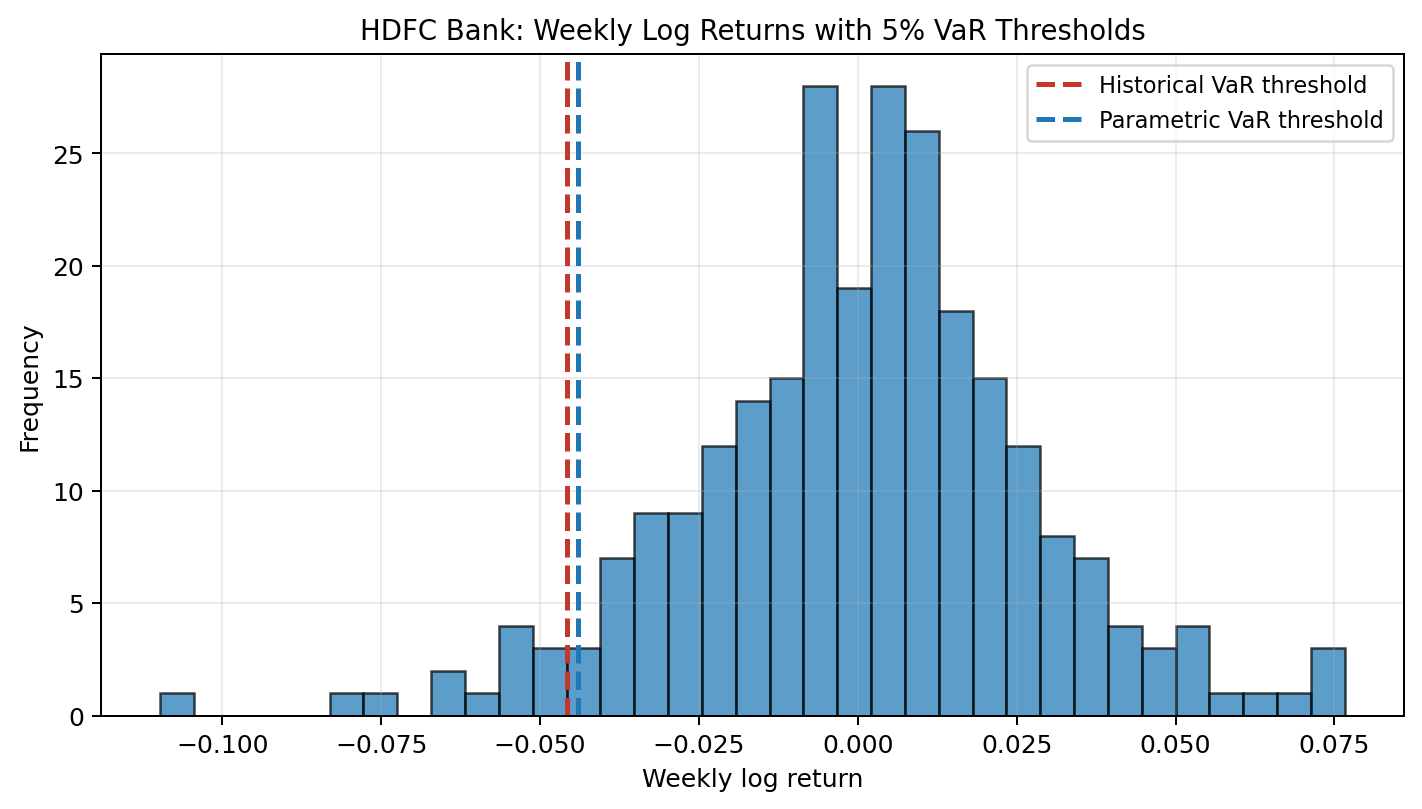

**Extreme tail observations: worst 5 weekly log returns**

,Price,Weekly Log Return
Date,,
2024-01-19,715.74,-0.10972
2023-09-22,744.46,-0.08283
2022-04-22,644.77,-0.07758
2026-01-09,939.00,-0.06454
2022-03-04,649.96,-0.06351


**Metric summary**

,Historical VaR,Historical CVaR,Parametric VaR,Parametric CVaR,Historical Tail Gap,Parametric Tail Gap,Historical Tail Amplification,Parametric Tail Amplification
Asset,,,,,,,,
HDFC Bank,0.04580,0.06315,0.04400,0.05535,0.01734,0.01135,1.37863,1.25798



**Observations for HDFC Bank (banking stock)**

- The 5% historical weekly loss threshold is about 0.0458, so the return-space cutoff is -0.0458.
- Historical weekly CVaR is 0.0631, which estimates the average weekly loss after crossing that cutoff.
- The historical weekly tail is heavier than the Gaussian tail based on CVaR (0.0631 vs 0.0553).
- Historical tail amplification is 1.38x, meaning CVaR is that multiple of historical VaR.


In [26]:
run_asset_block("HDFC Bank")

### HUL

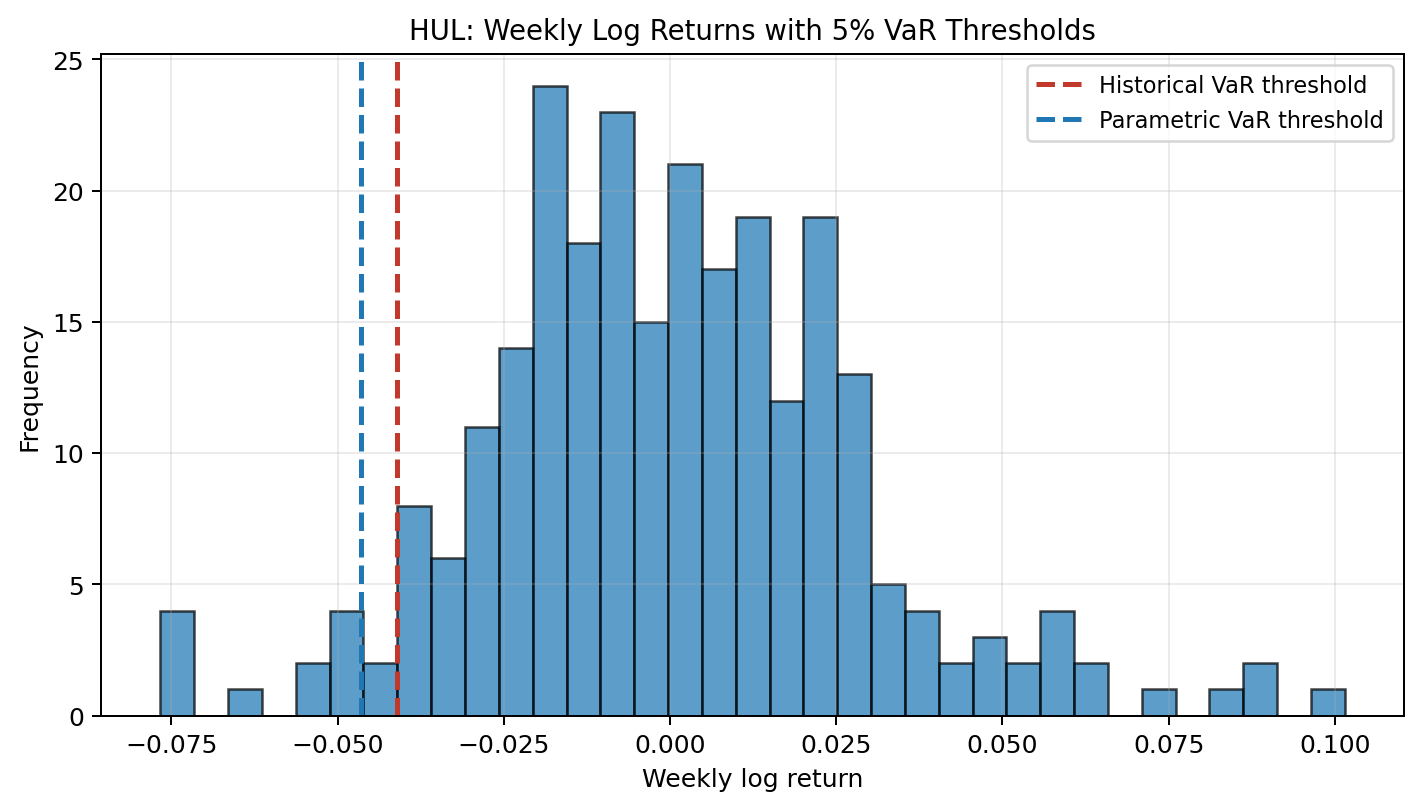

**Extreme tail observations: worst 5 weekly log returns**

,Price,Weekly Log Return
Date,,
2021-10-22,2273.13,-0.07663
2022-03-25,1820.10,-0.07355
2022-03-04,1882.08,-0.07220
2024-10-25,2453.68,-0.07212
2022-02-25,2022.99,-0.06330


**Metric summary**

,Historical VaR,Historical CVaR,Parametric VaR,Parametric CVaR,Historical Tail Gap,Parametric Tail Gap,Historical Tail Amplification,Parametric Tail Amplification
Asset,,,,,,,,
HUL,0.04111,0.05788,0.04648,0.05833,0.01677,0.01186,1.40792,1.25518



**Observations for HUL (FMCG stock)**

- The 5% historical weekly loss threshold is about 0.0411, so the return-space cutoff is -0.0411.
- Historical weekly CVaR is 0.0579, which estimates the average weekly loss after crossing that cutoff.
- The historical weekly tail is not heavier than the Gaussian tail based on CVaR (0.0579 vs 0.0583).
- Historical tail amplification is 1.41x, meaning CVaR is that multiple of historical VaR.


In [27]:
run_asset_block("HUL")

### TCS

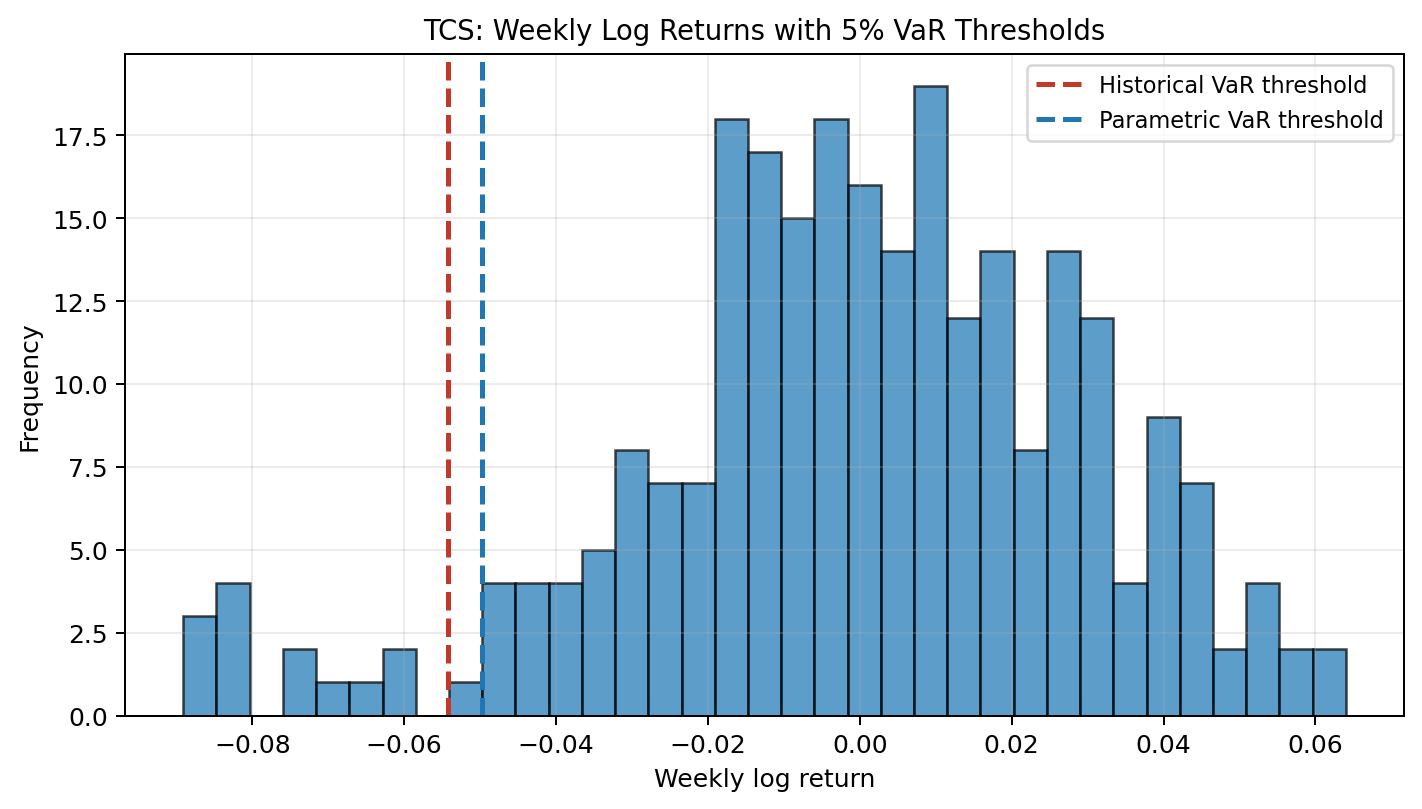

**Extreme tail observations: worst 5 weekly log returns**

,Price,Weekly Log Return
Date,,
2025-09-26,2836.76,-0.08908
2025-04-04,3189.18,-0.08890
2026-02-13,2692.20,-0.08859
2022-06-17,2763.17,-0.08410
2021-10-15,3203.37,-0.08405


**Metric summary**

,Historical VaR,Historical CVaR,Parametric VaR,Parametric CVaR,Historical Tail Gap,Parametric Tail Gap,Historical Tail Amplification,Parametric Tail Amplification
Asset,,,,,,,,
TCS,0.05425,0.07765,0.04973,0.06231,0.02339,0.01258,1.43121,1.25292



**Observations for TCS (IT stock)**

- The 5% historical weekly loss threshold is about 0.0543, so the return-space cutoff is -0.0543.
- Historical weekly CVaR is 0.0776, which estimates the average weekly loss after crossing that cutoff.
- The historical weekly tail is heavier than the Gaussian tail based on CVaR (0.0776 vs 0.0623).
- Historical tail amplification is 1.43x, meaning CVaR is that multiple of historical VaR.


In [28]:
run_asset_block("TCS")

## Cross-asset comparison

These plots compare weekly risk levels, the extra weekly loss beyond VaR, and the amplification from VaR to CVaR across the three sector stocks.

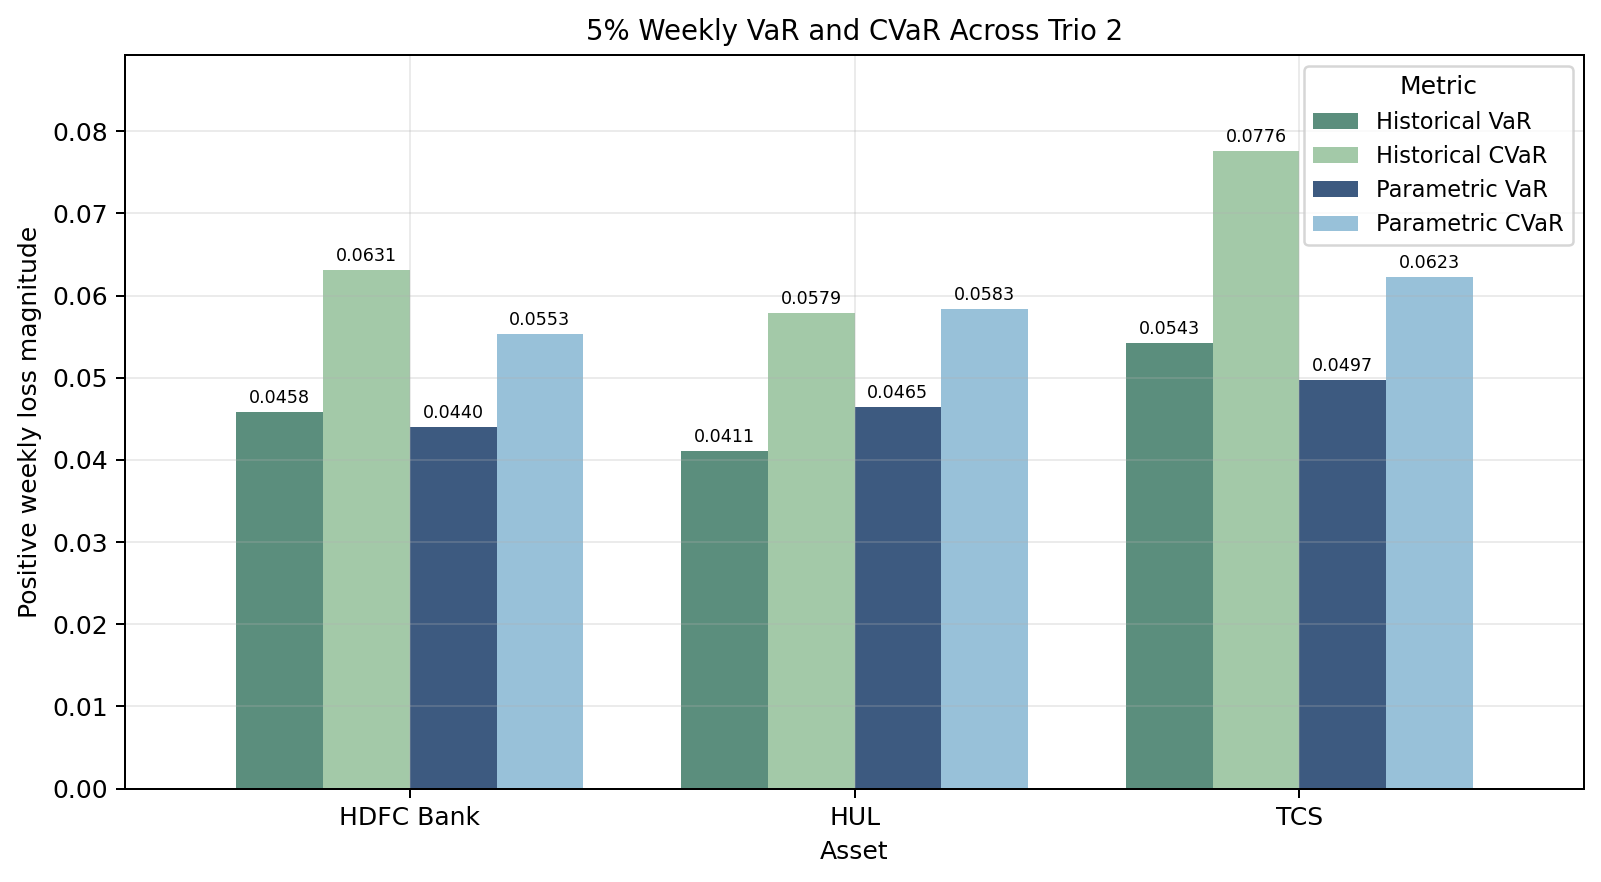

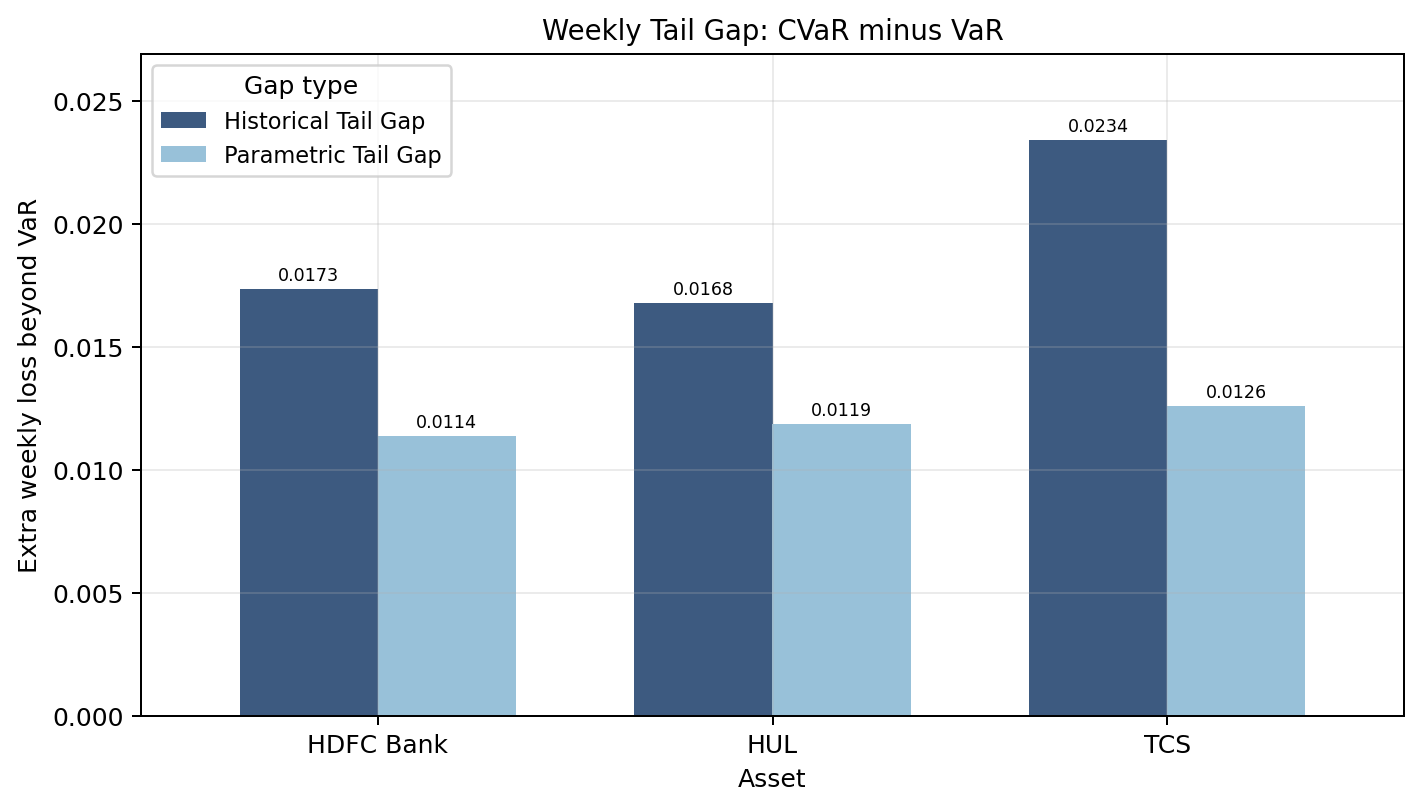

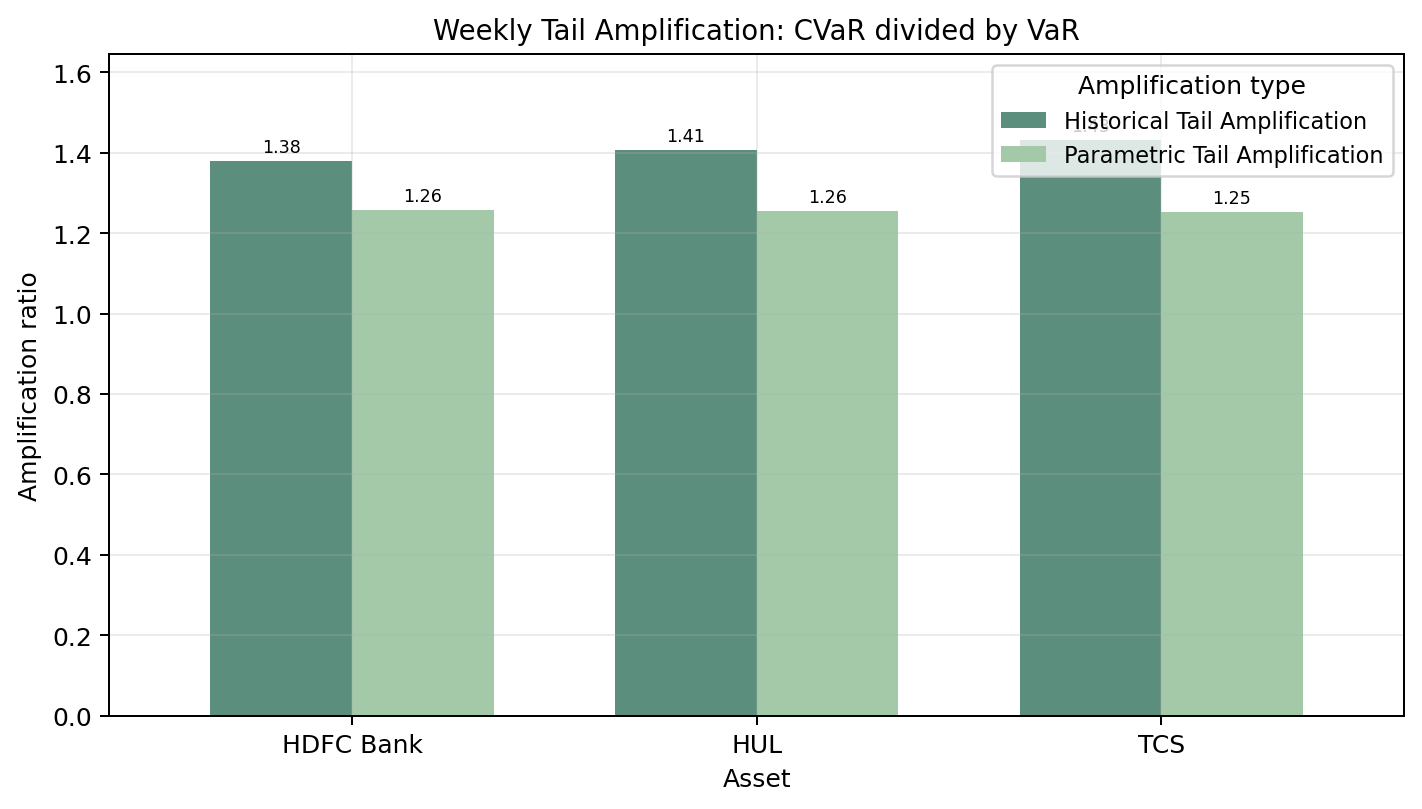

In [29]:
def add_bar_labels(ax, fmt="{:.4f}"):
    for container in ax.containers:
        labels = [fmt.format(value) for value in container.datavalues]
        ax.bar_label(container, labels=labels, padding=2, fontsize=7)
    ax.margins(y=0.15)


risk_cols = ["Historical VaR", "Historical CVaR", "Parametric VaR", "Parametric CVaR"]
risk_color = ["#5B8E7D", "#A3C9A8", "#3D5A80", "#98C1D9"]
ax = risk_table[risk_cols].plot(kind="bar", figsize=(9, 5), width=0.78, color=risk_color)

ax.set_title("5% Weekly VaR and CVaR Across Trio 2")
ax.set_xlabel("Asset")
ax.set_ylabel("Positive weekly loss magnitude")
ax.legend(title="Metric")
add_bar_labels(ax, "{:.4f}")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

gap_cols = ["Historical Tail Gap", "Parametric Tail Gap"]
ax = risk_table[gap_cols].plot(kind="bar", figsize=(8, 4.6), width=0.7, color=risk_color[2:])
ax.set_title("Weekly Tail Gap: CVaR minus VaR")
ax.set_xlabel("Asset")
ax.set_ylabel("Extra weekly loss beyond VaR")
ax.legend(title="Gap type")
add_bar_labels(ax, "{:.4f}")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

amp_cols = ["Historical Tail Amplification", "Parametric Tail Amplification"]
ax = risk_table[amp_cols].plot(kind="bar", figsize=(8, 4.6), width=0.7, color=risk_color[:2])
ax.set_title("Weekly Tail Amplification: CVaR divided by VaR")
ax.set_xlabel("Asset")
ax.set_ylabel("Amplification ratio")
ax.legend(title="Amplification type")
add_bar_labels(ax, "{:.2f}")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Cross-asset interpretation

The comments below are generated after the tables are calculated, so they reflect the actual weekly data.

In [30]:
def comparison_interpretation():
    highest_var = risk_table["Historical VaR"].idxmax()
    highest_cvar = risk_table["Historical CVaR"].idxmax()
    highest_amp = risk_table["Historical Tail Amplification"].idxmax()
    biggest_method_gap = (risk_table["Historical CVaR"] - risk_table["Parametric CVaR"]).abs().idxmax()

    hdfc_var = risk_table.loc["HDFC Bank", "Historical VaR"]
    hul_var = risk_table.loc["HUL", "Historical VaR"]
    tcs_var = risk_table.loc["TCS", "Historical VaR"]

    hdfc_text = "higher" if hdfc_var > hul_var else "lower"
    tcs_text = "higher" if tcs_var > hul_var else "lower"

    text = f"""
- {highest_var} has the highest 5% historical weekly VaR, so it has the highest weekly threshold risk in this trio.
- {highest_cvar} has the highest historical weekly CVaR, so its weekly losses beyond the threshold are most severe on average.
- {highest_amp} has the largest historical tail amplification ratio.
- HDFC Bank's weekly downside threshold risk is {hdfc_text} than HUL's in this sample.
- TCS's weekly downside threshold risk is {tcs_text} than HUL's in this sample.
- Historical and parametric CVaR differ most for {biggest_method_gap}, which is where the Gaussian weekly-tail assumption needs the most caution.
- Overall, this trio compares banking, FMCG, and IT stocks under the same weekly tail-risk framework.
"""
    return Markdown(text)


display(comparison_interpretation())


- TCS has the highest 5% historical weekly VaR, so it has the highest weekly threshold risk in this trio.
- TCS has the highest historical weekly CVaR, so its weekly losses beyond the threshold are most severe on average.
- TCS has the largest historical tail amplification ratio.
- HDFC Bank's weekly downside threshold risk is higher than HUL's in this sample.
- TCS's weekly downside threshold risk is higher than HUL's in this sample.
- Historical and parametric CVaR differ most for TCS, which is where the Gaussian weekly-tail assumption needs the most caution.
- Overall, this trio compares banking, FMCG, and IT stocks under the same weekly tail-risk framework.


## Conclusion

VaR identifies the cutoff for bad weekly losses at the selected tail level. CVaR extends VaR by measuring the average severity beyond that cutoff.

The trio comparison helps show how weekly downside risk differs between banking, FMCG, and IT stocks. Comparing historical and parametric results also helps check whether a Gaussian model is missing real weekly tail behavior.

## Key Findings

These bullet points are generated from the computed weekly results.

In [31]:
def key_findings():
    highest_var = risk_table["Historical VaR"].idxmax()
    lowest_var = risk_table["Historical VaR"].idxmin()
    highest_cvar = risk_table["Historical CVaR"].idxmax()
    highest_gap = risk_table["Historical Tail Gap"].idxmax()
    highest_amp = risk_table["Historical Tail Amplification"].idxmax()
    highest_vol = descriptive_table["Weekly Std Dev"].idxmax()
    biggest_param_diff = (risk_table["Historical VaR"] - risk_table["Parametric VaR"]).abs().idxmax()

    text = f"""
- Highest historical weekly VaR: {highest_var}.
- Lowest historical weekly VaR: {lowest_var}.
- Highest historical weekly CVaR: {highest_cvar}.
- Largest historical weekly tail gap: {highest_gap}.
- Largest historical weekly tail amplification: {highest_amp}.
- Highest weekly return volatility: {highest_vol}.
- Largest historical vs parametric weekly VaR difference: {biggest_param_diff}.
- CVaR is larger than VaR for each asset, so it gives a stricter view of extreme weekly downside loss.
"""
    return Markdown(text)


display(key_findings())


- Highest historical weekly VaR: TCS.
- Lowest historical weekly VaR: HUL.
- Highest historical weekly CVaR: TCS.
- Largest historical weekly tail gap: TCS.
- Largest historical weekly tail amplification: TCS.
- Highest weekly return volatility: TCS.
- Largest historical vs parametric weekly VaR difference: HUL.
- CVaR is larger than VaR for each asset, so it gives a stricter view of extreme weekly downside loss.
